### Make subsets based on FLAGS

# Imports and reads

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from utils.data_loader import load_parquet

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


## Flags

In [2]:
from utils.data_loader import load_flags
Shock, Helio, RC = load_flags()

Shock_flag = pd.to_datetime(Shock['Time'], errors='coerce')
Helios_shock_flag = pd.to_datetime(Helio['icme_start_time'], errors='coerce')
Helios_mostart_flag = pd.to_datetime(Helio['mo_start_time'], errors='coerce')
Helios_moend_flag = pd.to_datetime(Helio['mo_end_time'], errors='coerce')
RC_shock_flag = pd.to_datetime(RC['Disturbance_time'], errors='coerce')
RC_start_flag = pd.to_datetime(RC['ICME_Start'], errors='coerce')
RC_end_flag = pd.to_datetime(RC['ICME_End'], errors='coerce')

In [3]:
df = GFOC_data.copy()
time = df['time'].values

# make 'time' the index
df.set_index('time', inplace=True)
df.index = pd.to_datetime(df.index)

# Plot Data

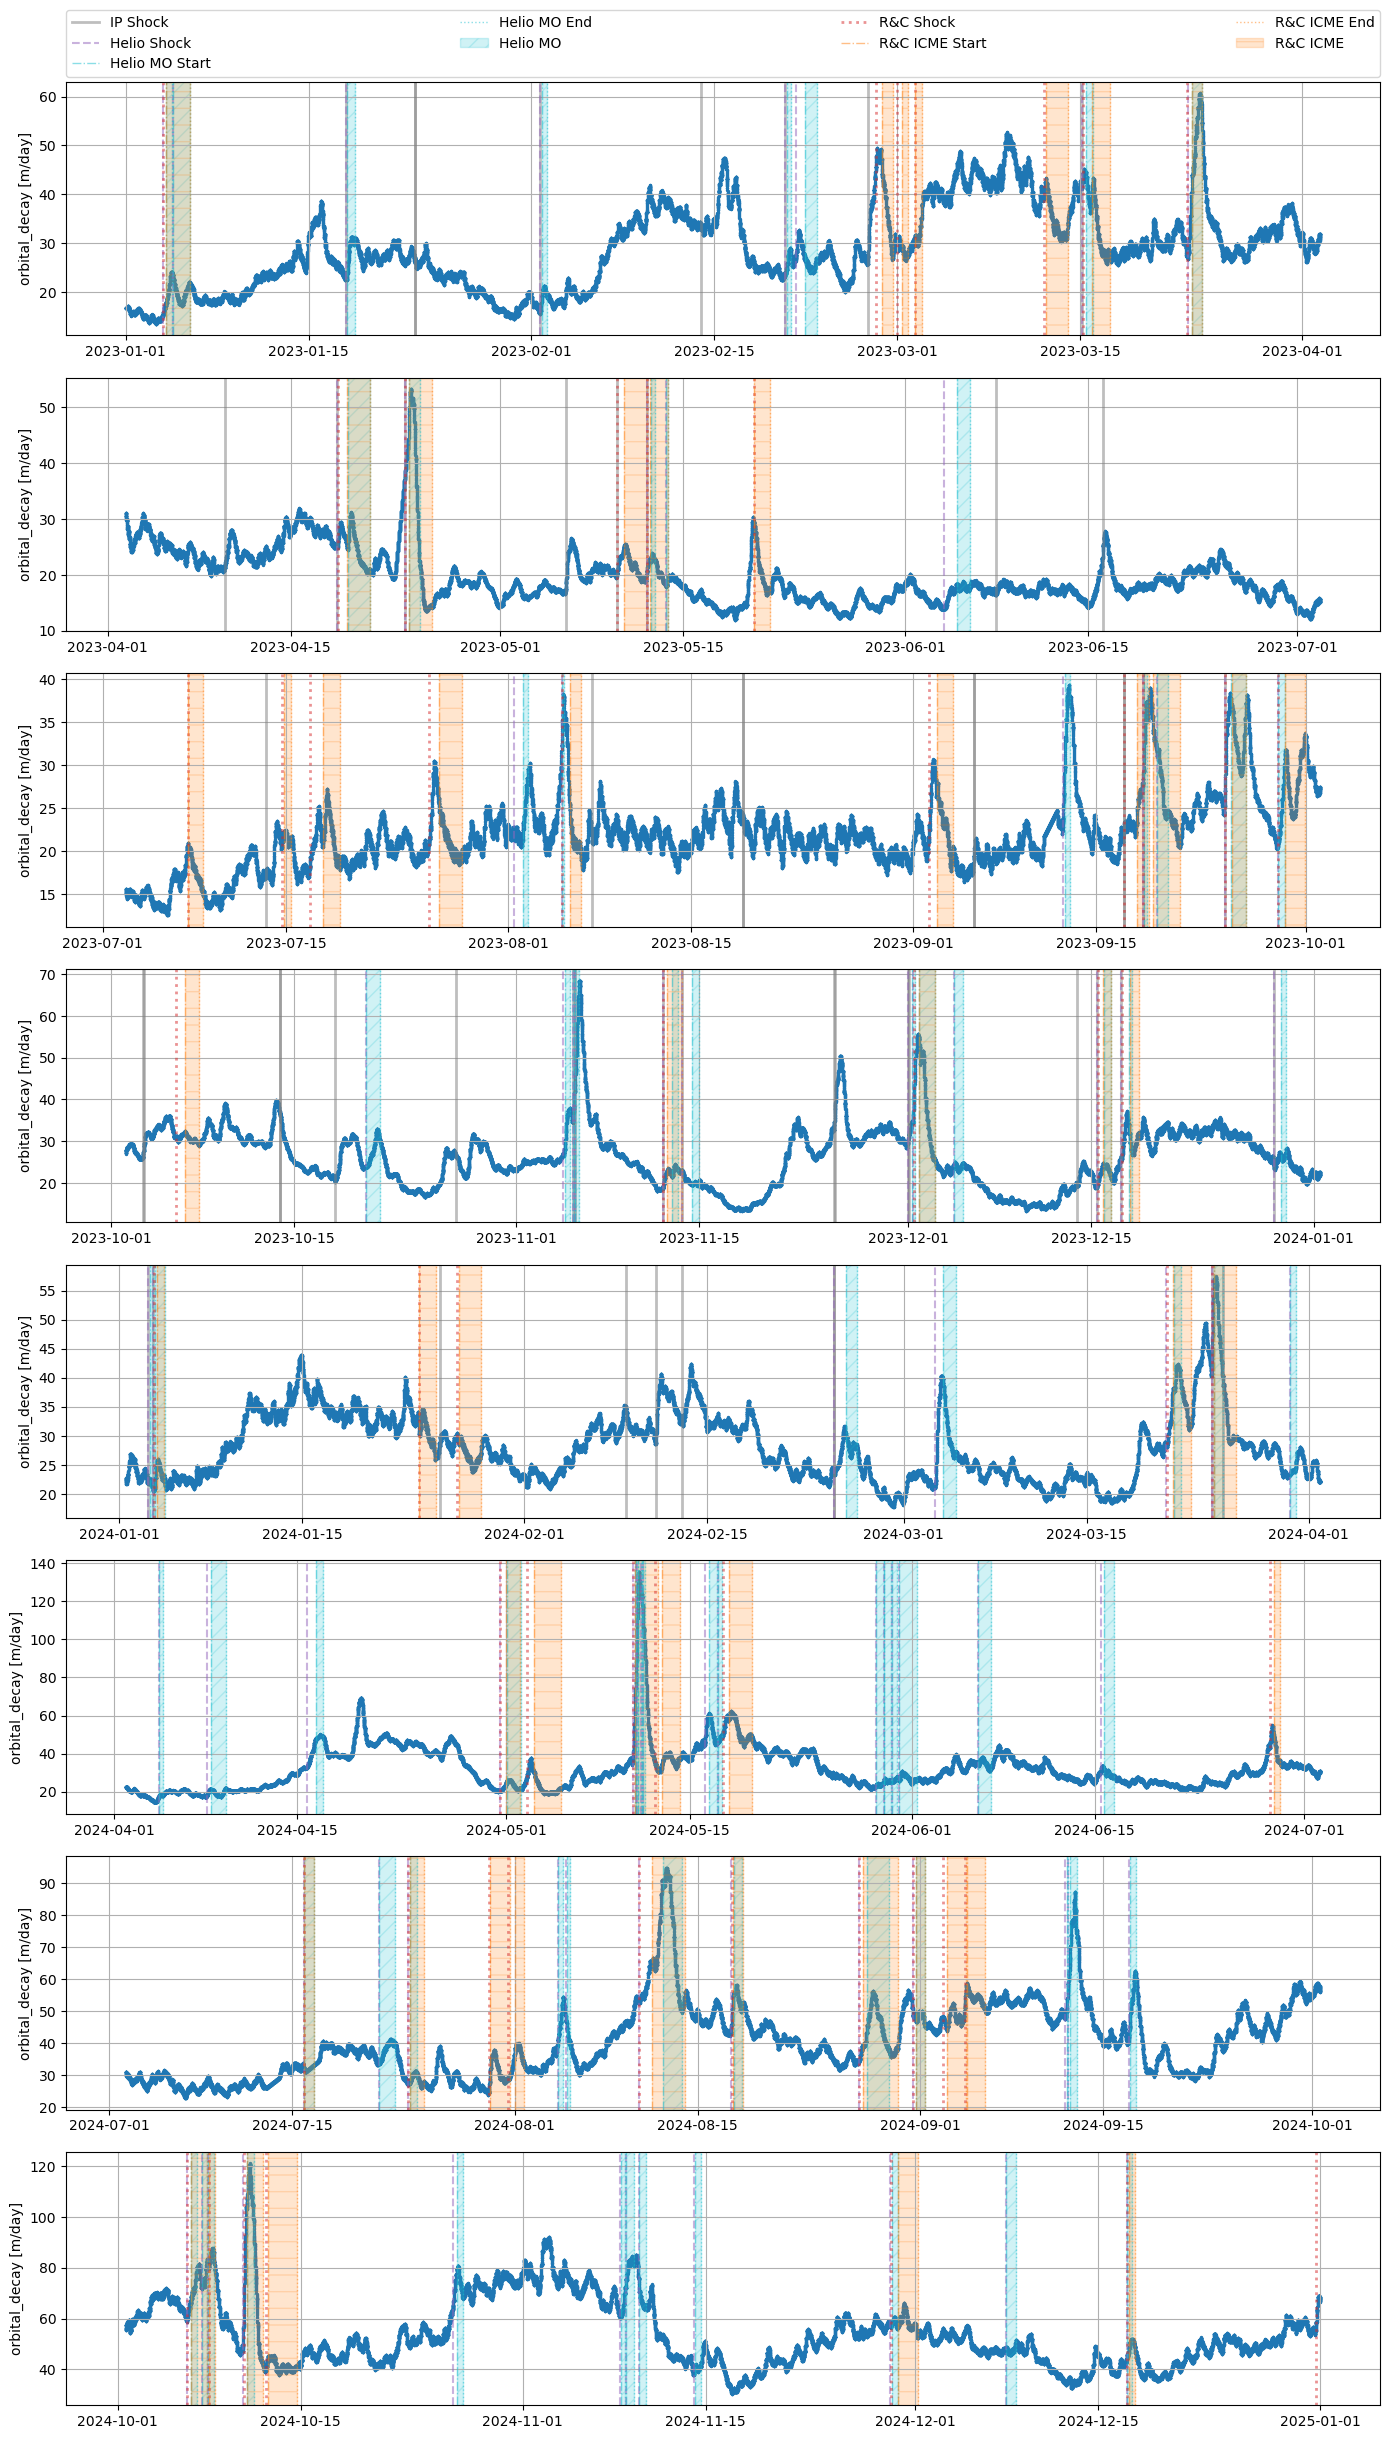

In [4]:
N = 8  # number of subplots

# Downsampled view
ysub = df.iloc[::8]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    # scatter plot
    ax.scatter(
        chunk.index,
        chunk['orbital_decay'],
        s=2,

    )

    # # highlight intervals for this subplot
    # for start, end in intervals:
    #     # only draw if this interval overlaps the current x-range
    #     if start <= chunk.index[-1] and end >= chunk.index[0]:
    #         ax.axvspan(start, end, color='lightgrey', alpha=0.3)

    for t in Shock_flag.dropna():
        if t <= chunk.index[-1] and t >= chunk.index[0]:
            ax.axvline(t, color='tab:gray', alpha=0.5, linestyle='-', linewidth=2, label='IP Shock')
    for t in Helios_shock_flag.dropna():
        if t <= chunk.index[-1] and t >= chunk.index[0]:
            ax.axvline(t, color='tab:purple', alpha=0.5, linestyle='--', linewidth=1.5, label='Helio Shock')
    for tstart, tend in zip(Helios_mostart_flag.dropna(), Helios_moend_flag.dropna()):
        if tstart <= chunk.index[-1] and tend >= chunk.index[0]:
            ax.axvline(tstart, color='tab:cyan', alpha=0.5, linestyle='-.', linewidth=1.0, label='Helio MO Start')
            ax.axvline(tend, color='tab:cyan', alpha=0.5, linestyle=':', linewidth=1.0, label='Helio MO End')
            ax.axvspan(tstart, tend, color='tab:cyan', alpha=0.2, hatch='//', label='Helio MO')
    for t in RC_shock_flag.dropna():
        if t <= chunk.index[-1] and t >= chunk.index[0]:
            ax.axvline(t, color='tab:red', alpha=0.5, linestyle=':', linewidth=2.0, label='R&C Shock')
    for tstart, tend in zip(RC_start_flag.dropna(), RC_end_flag.dropna()):
        if tstart <= chunk.index[-1] and tend >= chunk.index[0]:
            ax.axvline(tstart, color='tab:orange', alpha=0.5, linestyle='-.', linewidth=1.0, label='R&C ICME Start')
            ax.axvline(tend, color='tab:orange', alpha=0.5, linestyle=':', linewidth=1.0, label='R&C ICME End')
            ax.axvspan(tstart, tend, color='tab:orange', alpha=0.2, hatch='-', label='R&C ICME')

    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(),
    bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
    ncols=4, mode="expand", borderaxespad=0.)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()

# Create subsets

In [5]:
df['flag'] = 0

# shock flags
all_shocks = pd.to_datetime(pd.concat([
    Shock_flag,
    Helios_shock_flag,
    RC_shock_flag
], ignore_index=True)).dropna()
# round to nearest index time
all_shocks = df.index.intersection(all_shocks)
df.loc[df.index.isin(all_shocks), 'flag'] = 1

# mo flags
interval_starts = pd.to_datetime(pd.concat([
    Helios_mostart_flag,
    RC_start_flag
], ignore_index=True)).dropna()

interval_ends = pd.to_datetime(pd.concat([
    Helios_moend_flag,
    RC_end_flag
], ignore_index=True)).dropna()

intervals = list(zip(interval_starts, interval_ends))
for start, end in intervals:
    df.loc[(df.index >= start) & (df.index <= end), 'flag'] = 1

## Create extended flag

In [6]:
df['e_flag'] = 0

t01 = pd.Timedelta(hours=2)  # extension before 0->1
t10 = pd.Timedelta(hours=12)  # extension after 1->0
# mo flags
interval_starts = pd.to_datetime(pd.concat([
    Helios_mostart_flag-t01,
    RC_start_flag-t01,
    Shock_flag-t01,
    Helios_shock_flag-t01,
    RC_shock_flag-t01
], ignore_index=True)).dropna()

interval_ends = pd.to_datetime(pd.concat([
    Helios_moend_flag+t10,
    RC_end_flag+t10,
    Shock_flag+t10,
    Helios_shock_flag+t10,
    RC_shock_flag+t10
], ignore_index=True)).dropna()

intervals = list(zip(interval_starts, interval_ends))
for start, end in intervals:
    df.loc[(df.index >= start) & (df.index <= end), 'e_flag'] = 1

In [7]:
def find_intervals(dataframe, col='std_flag', min_duration=pd.Timedelta(days=1), threshold=[0]):
    mask = ~dataframe[col].isin(threshold)
    new_group = (mask != mask.shift()).cumsum()
    active = mask.groupby(new_group)
    active_groups = [g.index for _, g in dataframe[mask].groupby(new_group[mask])]
    long_segments = [
        seg
        for seg in active_groups
        if seg[-1] - seg[0] >= min_duration
    ]
    intervals = [(seg[0], seg[-1]) for seg in long_segments]
    return intervals

intervals = find_intervals(df, col='e_flag', min_duration=pd.Timedelta(days=2), threshold=[0])
# save intervals to csv
intervals_df = pd.DataFrame(intervals, columns=['start', 'end'])
intervals_df.to_csv('./Analysis/modeling/subsets_eflag.csv', index=False)

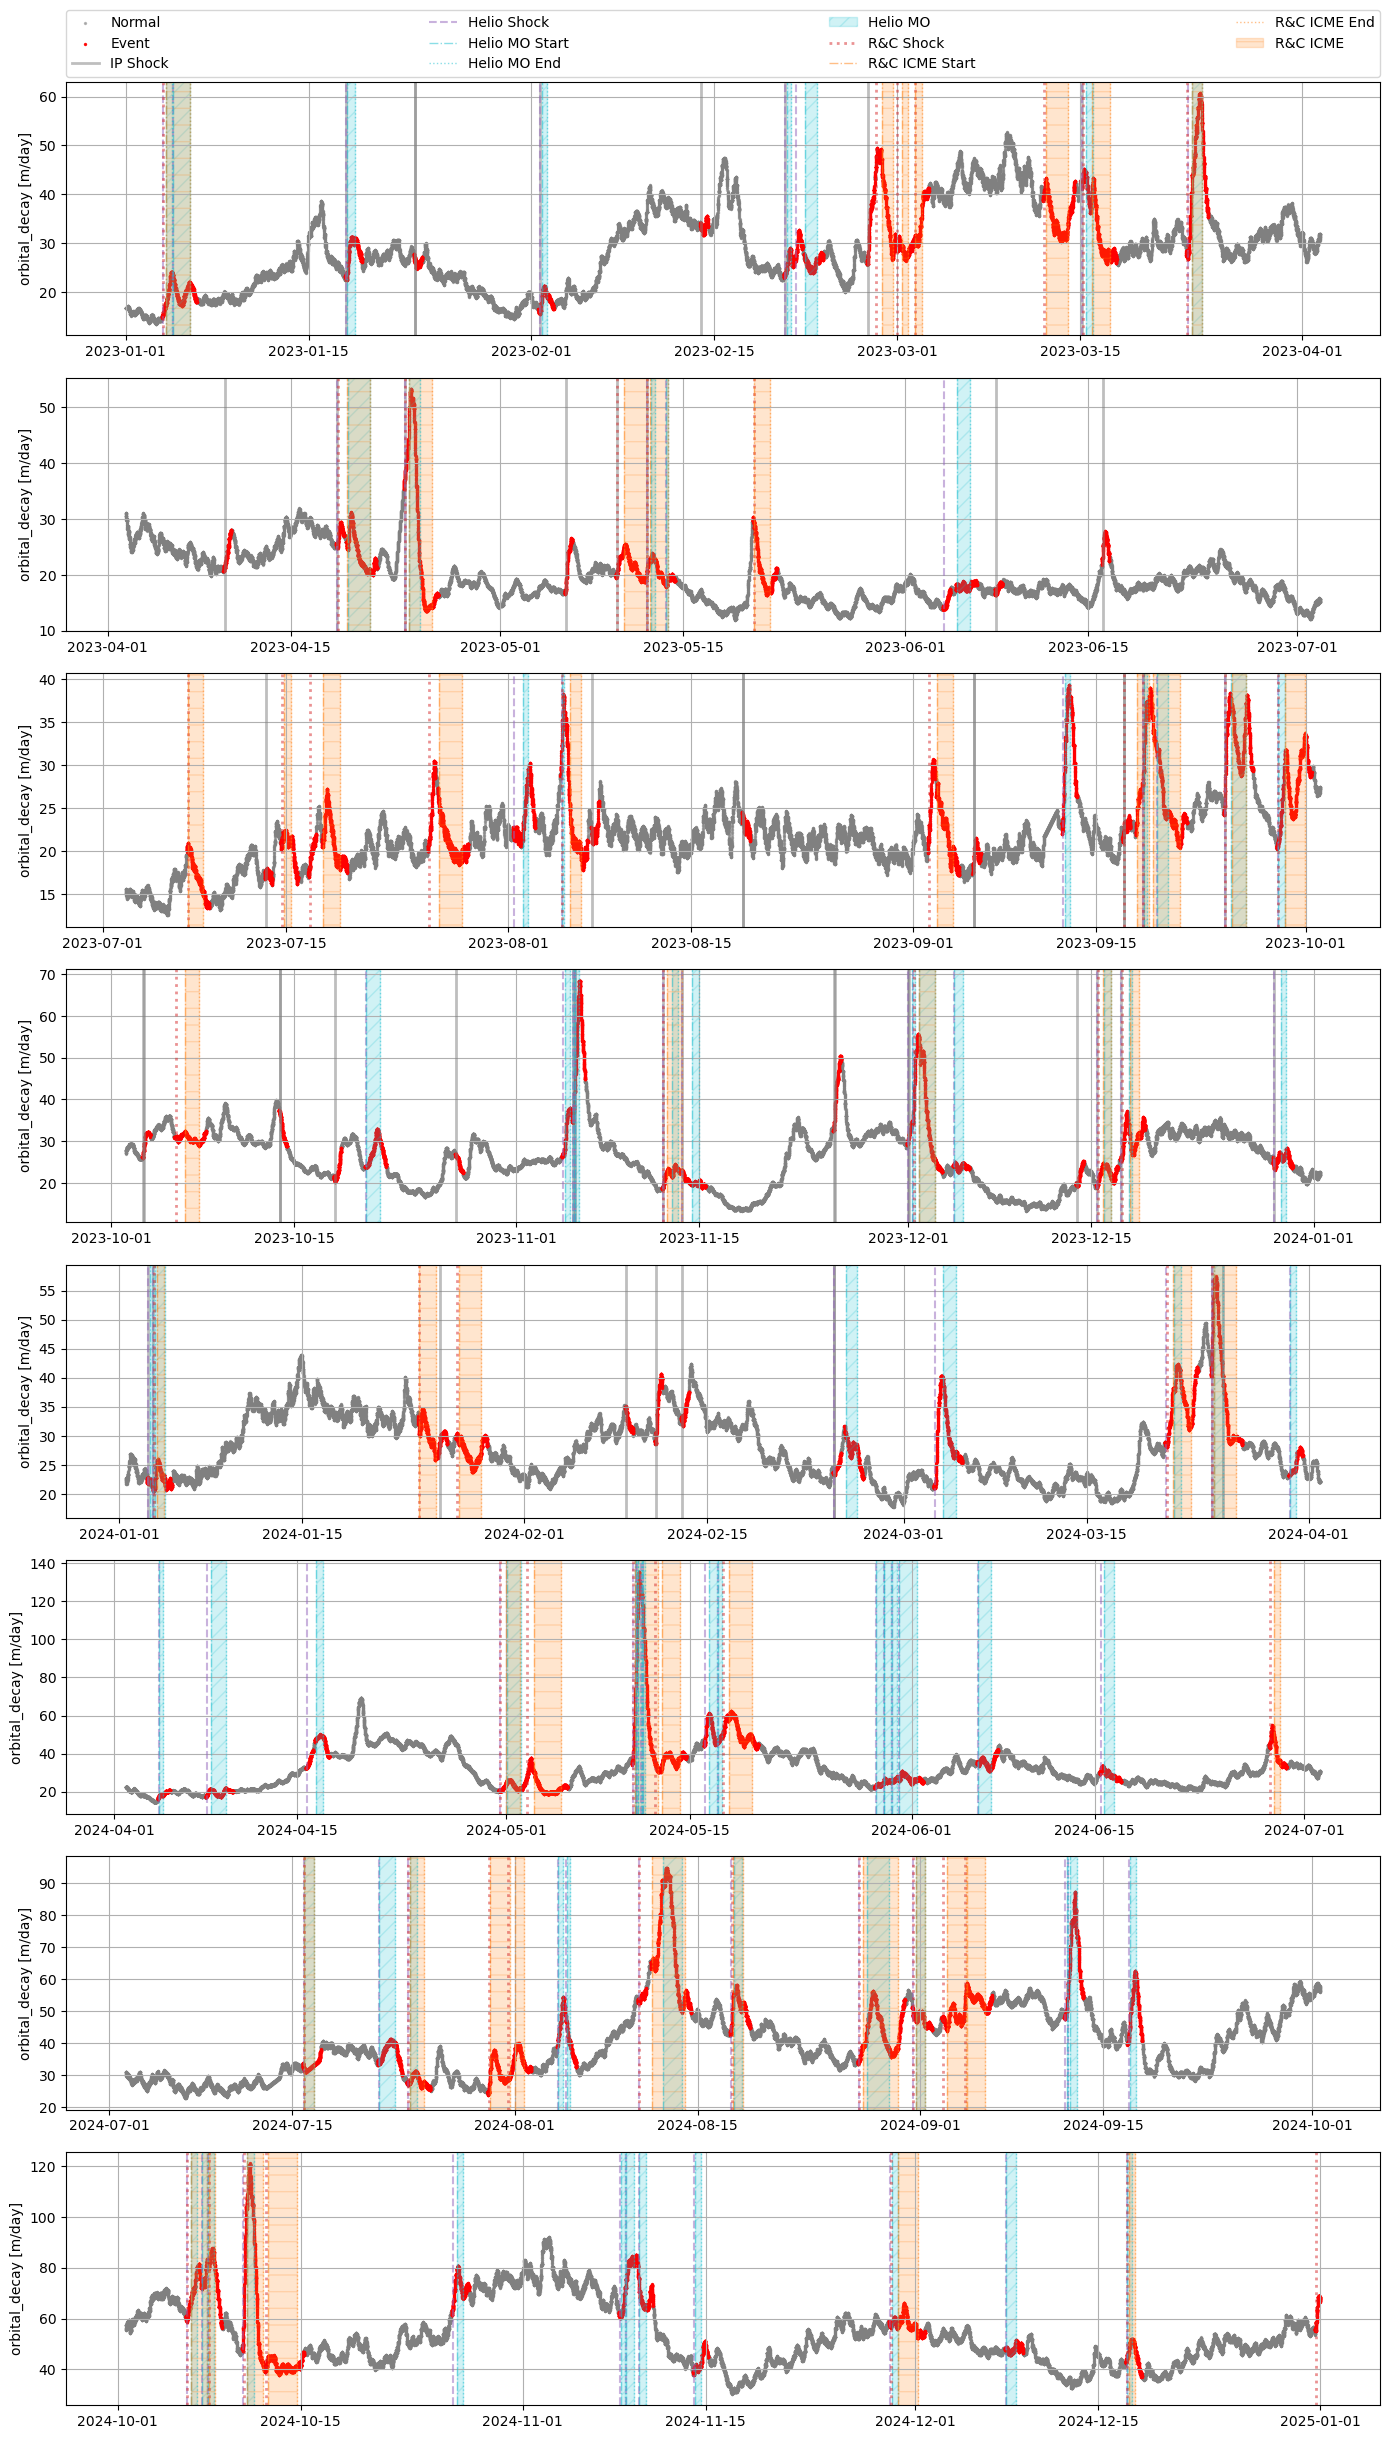

In [8]:
N = 8  # number of subplots

# Downsampled view
ysub = df.iloc[::8]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    flagged   = chunk[chunk['e_flag'] == 1]
    unflagged = chunk[chunk['e_flag'] == 0]

    ax.scatter(
        unflagged.index,
        unflagged['orbital_decay'],
        s=2,
        color='gray',
        alpha=0.5,
        label='Normal'
    )

    ax.scatter(
        flagged.index,
        flagged['orbital_decay'],
        s=2,
        color='red',
        alpha=0.9,
        label='Event'
    )

    for t in Shock_flag.dropna():
        if t <= chunk.index[-1] and t >= chunk.index[0]:
            ax.axvline(t, color='tab:gray', alpha=0.5, linestyle='-', linewidth=2, label='IP Shock')
    for t in Helios_shock_flag.dropna():
        if t <= chunk.index[-1] and t >= chunk.index[0]:
            ax.axvline(t, color='tab:purple', alpha=0.5, linestyle='--', linewidth=1.5, label='Helio Shock')
    for tstart, tend in zip(Helios_mostart_flag.dropna(), Helios_moend_flag.dropna()):
        if tstart <= chunk.index[-1] and tend >= chunk.index[0]:
            ax.axvline(tstart, color='tab:cyan', alpha=0.5, linestyle='-.', linewidth=1.0, label='Helio MO Start')
            ax.axvline(tend, color='tab:cyan', alpha=0.5, linestyle=':', linewidth=1.0, label='Helio MO End')
            ax.axvspan(tstart, tend, color='tab:cyan', alpha=0.2, hatch='//', label='Helio MO')
    for t in RC_shock_flag.dropna():
        if t <= chunk.index[-1] and t >= chunk.index[0]:
            ax.axvline(t, color='tab:red', alpha=0.5, linestyle=':', linewidth=2.0, label='R&C Shock')
    for tstart, tend in zip(RC_start_flag.dropna(), RC_end_flag.dropna()):
        if tstart <= chunk.index[-1] and tend >= chunk.index[0]:
            ax.axvline(tstart, color='tab:orange', alpha=0.5, linestyle='-.', linewidth=1.0, label='R&C ICME Start')
            ax.axvline(tend, color='tab:orange', alpha=0.5, linestyle=':', linewidth=1.0, label='R&C ICME End')
            ax.axvspan(tstart, tend, color='tab:orange', alpha=0.2, hatch='-', label='R&C ICME')

    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(),
    bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
    ncols=4, mode="expand", borderaxespad=0.)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()